## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import random

In [2]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

which_dataset = config["which_dataset"]
preprocessing_method = config["preprocessing_method"] # normalization / logarithm
remove_outer_bool = config["remove_outer"]
how_many_outer_to_remove = config["how_many_outer_to_remove"]
elements_to_keep = config["elements_to_keep"]

data_path = config["data_path"][which_dataset]
results_path = config["results_path"]
figures_path = config["figures_path"]
models_path = config["models_path"]

In [3]:
columns_to_keep_inds = [el + '_i' for el in elements_to_keep]
columns_to_keep_inks = [el + '_a' for el in elements_to_keep]

## Loading the data

In [4]:
df = pd.read_csv(data_path)
inks_df = df[[col for col in df.columns if col.endswith('_a')]]
inks_df.columns = [col.split('_')[0] for col in inks_df.columns]
inds_df = df[[col for col in df.columns if col.endswith('_i')]]
inds_df.columns = [col.split('_')[0] for col in inds_df.columns]

if which_dataset == 'old':
    df['sample_i'] = df['inds'].apply(lambda x: x.split('.')[0])
    df['sample_a'] = df['sample_i']
    df.rename(columns={'inds': 'name'}, inplace=True)

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [5]:
inDKs_df = df

### Keeping track of the records from the same sample

Check

In [6]:
if which_dataset == 'old':
    all(inDKs_df['sample_i'] == inDKs_df['sample_a'])
if which_dataset == 'new':
    all(inDKs_df['name_i'].apply(lambda x: (x.split('_')[0]).split('.')[0]) == inDKs_df['name_a'].apply(lambda x: (x.split('_')[0]).split('.')[0]))

We can use adjusted 'name' column as sample id:

In [7]:
if which_dataset == 'old':
    inDKs_df['Sample_id'] = inDKs_df['sample_i']
if which_dataset == 'new':
    inDKs_df['Sample_id'] = inDKs_df['name_i'].apply(lambda x: (x.split('_')[0]).split('.')[0])
    inDKs_df['name'] = inDKs_df['Sample_id'] + '_' + inDKs_df['name_i'].apply(lambda x: x.split('_')[-1])

### Removing some data

1. Let's remove 'outer' samples:

In [8]:
def remove_outer(group, n):
    return group.iloc[n:-n] if len(group) > 2*n else pd.DataFrame(columns=group.columns)

In [9]:
if remove_outer_bool:
    inDKs_df = inDKs_df.groupby('Sample_id', group_keys=False).apply(remove_outer, n=how_many_outer_to_remove)

2. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [10]:
inDKs_df = inDKs_df[columns_to_keep_inks + columns_to_keep_inds + ['Sample_id', 'name'] ]

3. Let's remove rows with missing values.

In [11]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.0

4. Let's set negative numbers to zeros.

In [12]:
(inDKs_df[columns_to_keep_inks + columns_to_keep_inds]<0).sum().sum() == 0

np.True_

In [13]:
for col in columns_to_keep_inks + columns_to_keep_inds:
    inDKs_df[col][inDKs_df[col] < 0] = 0

/tmp/ipykernel_8743/1556174307.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  inDKs_df[col][inDKs_df[col] < 0] = 0
/tmp/ipykernel_8743/1556174307.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

5. (Optionally) let's set indicators to zero if the corresponding ink is zero.

In [14]:
# for i in range(len(elements_to_keep)):
#     inDKs_df.iloc[:,i+8] = np.where(inDKs_df.iloc[:,i]!=0, inDKs_df.iloc[:,i+8], 0)

In [15]:
#check
# element = 'Pb'
# inDKs_df[element + '_i'][np.logical_and(inDKs_df[element + '_a']==0, inDKs_df[element + '_i']!=0)]

### Train test split, datasets, dataloaders

In [16]:
indices = list(range(int(inDKs_df.shape[0])))
ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)

partition = {'train': ind_train_all,
         'val': ind_val_all,
        'test': ind_test_all}

X_y_train = inDKs_df.iloc[partition['train'],:]
X_y_val = inDKs_df.iloc[partition['val'],:]
X_y_test = inDKs_df.iloc[partition['test'],:]

X_y_train.reset_index(drop=True, inplace=True)
X_y_val.reset_index(drop=True, inplace=True)
X_y_test.reset_index(drop=True, inplace=True)

### Creating features and labels matrices

In [17]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']

X_train = np.array(X_y_train[columns_to_keep_inds].values)
y_train = np.array(X_y_train[columns_to_keep_inks].values)
X_val = np.array(X_y_val[columns_to_keep_inds].values)
y_val = np.array(X_y_val[columns_to_keep_inks].values)
X_test = np.array(X_y_test[columns_to_keep_inds].values)
y_test = np.array(X_y_test[columns_to_keep_inks].values)

### Normalization / taking logarithm

In [18]:
def adjusted_log_transform(input_array):
    res = np.where(input_array>0, np.log(input_array), 0.)
    #res = np.where(input_array<=0, input_array + res.min(axis=0), res)
    return res

In [19]:
if preprocessing_method == 'normalization':

    X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
    y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    X_train = adjusted_log_transform(X_train)
    y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)
    
elif preprocessing_method == 'logarithm_and_normalization':
    
    #logarithm
    X_train = adjusted_log_transform(X_train)
    y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)
    
    #normalization
    X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
    y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)

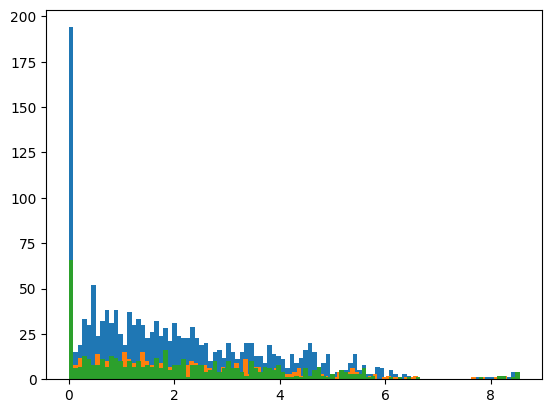

In [20]:
dim = 6
plt.hist(X_train[:,dim], bins=100);
plt.hist(X_test[:,dim], bins=100);
plt.hist(X_val[:,dim], bins=100);

#np.argwhere(X_train[:,2]<-20)

### Converting to tensors

In [21]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [22]:
X_train = torch.Tensor(X_train).to(device)
y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

### Dataset

In [23]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [24]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [25]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [26]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [27]:
dropout_prob = 0.02

class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(64, 128),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(128, 256),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(256, 512),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(512, 1024),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(1024, 512),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [28]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): Dropout(p=0.02, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): Dropout(p=0.02, inplace=False)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=128, bias=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=256, bias=True)
    (10): Dropout(p=0.02, inplace=False)
    (11): ReLU()
    (12): Linear(in_features=256, out_features=512, bias=True)
    (13): Dropout(p=0.02, inplace=False)
    (14): ReLU()
    (15): Linear(in_features=512, out_features=1024, bias=True)
    (16): Dropout(p=0.02, inplace=False)
    (17): ReLU()
    (18): Linear(in_features=1024, out_features=512, bias=True)
    (19): Dropout(p=0.02, inplace=False)
    (20): ReLU()
    (21): Linear(in_features=512, out_features=256, bias=True)
    (22): Dropout(p=0.02, inplace=False)
    (23): ReLU()
    (24): Linear

In [29]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

In [30]:
weights = torch.tensor([1/input_size]*input_size).unsqueeze(1).to(device)

class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [31]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 5.290716012318929 test 1.93526969997519
EPOCH 2:
LOSS train 1.997374693552653 test 1.513532555421672
EPOCH 3:
LOSS train 1.622807534535726 test 1.3454212641297094
EPOCH 4:
LOSS train 1.5220223426818849 test 1.278075288048231
EPOCH 5:
LOSS train 1.4653218746185304 test 1.2529561831110931
EPOCH 6:
LOSS train 1.4359225432078044 test 1.1923705577993966
EPOCH 7:
LOSS train 1.3727312088012695 test 1.1850665286548405
EPOCH 8:
LOSS train 1.374232323964437 test 1.2811721247584225
EPOCH 9:
LOSS train 1.3891080300013223 test 1.1537530789928263
EPOCH 10:
LOSS train 1.3516118049621582 test 1.1390649524019905
EPOCH 11:
LOSS train 1.2918548186620076 test 1.1563081091103784
EPOCH 12:
LOSS train 1.302743379275004 test 1.131150542271574
EPOCH 13:
LOSS train 1.2989078839619954 test 1.1821807924989447
EPOCH 14:
LOSS train 1.2962898095448812 test 1.1467077026128336
EPOCH 15:
LOSS train 1.301695704460144 test 1.1864092691865074
EPOCH 16:
LOSS train 1.3068687518437703 test 1.3276534947553

In [32]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 4.250659020050712 test 1.9926959179864039
EPOCH 2:
LOSS train 1.7127212596976238 test 1.3962700011144633
EPOCH 3:
LOSS train 1.5148600858190786 test 1.2666459255450795
EPOCH 4:
LOSS train 1.504564492598824 test 1.3329125569452291
EPOCH 5:
LOSS train 1.4732896348704463 test 1.4787842440395458
EPOCH 6:
LOSS train 1.4762397538060728 test 1.5092732615948368
EPOCH 7:
LOSS train 1.437254599902941 test 1.2491415238211054
EPOCH 8:
LOSS train 1.436557184094968 test 1.4929533293234316
EPOCH 9:
LOSS train 1.4732615325761877 test 1.2877731693387837
EPOCH 10:
LOSS train 1.4181078309598176 test 1.2384409723899683
EPOCH 11:
LOSS train 1.409985547480376 test 1.3115588232241722
EPOCH 12:
LOSS train 1.4060250054235044 test 1.2421920496927061
EPOCH 13:
LOSS train 1.4285200782444165 test 1.2818971221647018
EPOCH 14:
LOSS train 1.3963128794794497 test 1.282081372070861
EPOCH 15:
LOSS train 1.435877343882685 test 1.2164265244142611
EPOCH 16:
LOSS train 1.372760824535204 test 1.2130138585

In [33]:
EPOCHS = 2000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 2.7328393919901415 test 1.3246187387851318
EPOCH 2:
LOSS train 1.3314167017286473 test 1.196975134050073
EPOCH 3:
LOSS train 1.3036474152044817 test 1.1909243080827563
EPOCH 4:
LOSS train 1.2801118926568464 test 1.1967097081220597
EPOCH 5:
LOSS train 1.2964049631899053 test 1.184057790640678
EPOCH 6:
LOSS train 1.2923493412407963 test 1.1868866145761348
EPOCH 7:
LOSS train 1.2978052225979892 test 1.2067592411350472
EPOCH 8:
LOSS train 1.2586855563250454 test 1.1894703015953607
EPOCH 9:
LOSS train 1.2530872957272963 test 1.1797752511841038
EPOCH 10:
LOSS train 1.2467683418230577 test 1.215721845792829
EPOCH 11:
LOSS train 1.237746463580565 test 1.1748143719658508
EPOCH 12:
LOSS train 1.2271138971502131 test 1.2557903892993927
EPOCH 13:
LOSS train 1.2370041419159283 test 1.2074947168253387
EPOCH 14:
LOSS train 1.2211016064340419 test 1.1729432572049086
EPOCH 15:
LOSS train 1.2308877733620731 test 1.18364943839869
EPOCH 16:
LOSS train 1.2225864773446864 test 1.21851657

In [ ]:
##############################################################################

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

In [31]:
#%matplotlib widget

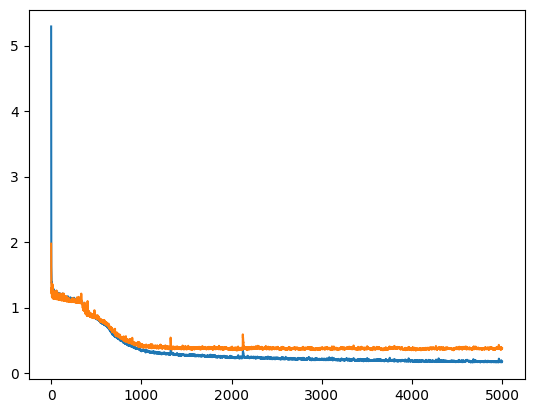

In [32]:
plt.plot(train_losses)
plt.plot(val_losses)

## Loading pretrained model

In [51]:
# path = models_path[object_name] + 'model_regression_Documents_XVIII_century_sample_split_logarithm_outer_removed_Al_S_Cr_Mn_Co_Cu_Zn_Pb_2025_03_10_20_49_57'

# model = InksNet().to(device)
# model.load_state_dict(torch.load(path))

/tmp/ipykernel_19958/850489444.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path))


<All keys matched successfully>

## Prediction on test set

In [33]:
model.eval()
loss_fn = CustomLoss()

running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    else:
        res = torch.concat((res, abs(outputs-labels)), axis=0)
        lab = torch.concat((lab, labels), axis=0)
        out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [34]:
lab

tensor([[ 8.4423,  6.2110,  0.8139,  ...,  6.9157,  6.4297,  7.2532],
        [ 9.2529,  6.7072,  1.6522,  ...,  6.7020,  4.1986,  9.5907],
        [ 7.7860,  6.3128,  0.1764,  ...,  6.6421,  4.2571,  6.5997],
        ...,
        [ 8.3831,  6.4586,  0.8281,  ...,  5.8056,  4.4160,  7.5516],
        [10.0224,  8.0365,  2.5609,  ...,  7.7423,  5.0974,  9.0747],
        [ 8.6278,  6.9695,  0.6588,  ...,  8.3229,  7.0599,  7.8435]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [35]:
out

tensor([[8.6688e+00, 6.3707e+00, 1.5959e+00,  ..., 6.9681e+00, 6.4102e+00,
         7.2944e+00],
        [8.9255e+00, 6.6337e+00, 1.6722e+00,  ..., 6.5351e+00, 3.9068e+00,
         9.3451e+00],
        [7.8289e+00, 6.5211e+00, 8.3172e-04,  ..., 6.6864e+00, 4.9499e+00,
         6.6335e+00],
        ...,
        [8.4271e+00, 6.5968e+00, 1.8527e+00,  ..., 5.8657e+00, 4.3712e+00,
         7.6147e+00],
        [9.8242e+00, 7.9440e+00, 2.6761e+00,  ..., 7.4867e+00, 4.9564e+00,
         8.8451e+00],
        [8.4589e+00, 6.9317e+00, 6.5074e-01,  ..., 8.2457e+00, 6.9795e+00,
         7.4168e+00]], device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [36]:
res

tensor([[0.2265, 0.1597, 0.7820,  ..., 0.0524, 0.0195, 0.0412],
        [0.3275, 0.0736, 0.0200,  ..., 0.1669, 0.2917, 0.2456],
        [0.0429, 0.2083, 0.1756,  ..., 0.0443, 0.6928, 0.0338],
        ...,
        [0.0440, 0.1382, 1.0246,  ..., 0.0601, 0.0448, 0.0631],
        [0.1982, 0.0926, 0.1152,  ..., 0.2556, 0.1410, 0.2296],
        [0.1689, 0.0377, 0.0080,  ..., 0.0772, 0.0804, 0.4267]],
       device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [37]:
torch.mean(res, axis=0)  # 6 elements, 0 in ink => 0 in ind

tensor([0.2565, 0.3501, 0.7424, 0.2533, 0.3758, 0.3519, 0.4101, 0.3288],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [40]:
torch.mean(res, axis=0)  # 8 elements, 0 in ink => 0 in ind

tensor([0.6500, 0.6265, 0.9034, 0.5394, 0.7739, 0.5944, 0.7455, 0.6623],
       grad_fn=<MeanBackward1>)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Significance of elements: Cu >> Mn > Al > Zn > Pb > S > Cr > Co >> all the others.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [38]:
torch.mean(res)

tensor(0.3836, device='cuda:0', grad_fn=<MeanBackward0>)

## Saving the model

In [39]:
outer_removed = 'outer_removed' if remove_outer else 'outer_not_removed'

elements = '_'.join(elements_to_keep)
settings_str = '_' + preprocessing_method + '_' + \
                outer_removed + '_' + str(how_many_outer_to_remove) + \
                '_' + elements + '_'

import time
ts = time.time()
import datetime
now = datetime.datetime.fromtimestamp(ts).strftime('%Y_%m_%d_%H_%M_%S')

torch.save(model.state_dict(), models_path + 'model_regression' + settings_str + now)

### Visualisations

In [40]:
dim_nr = 7
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

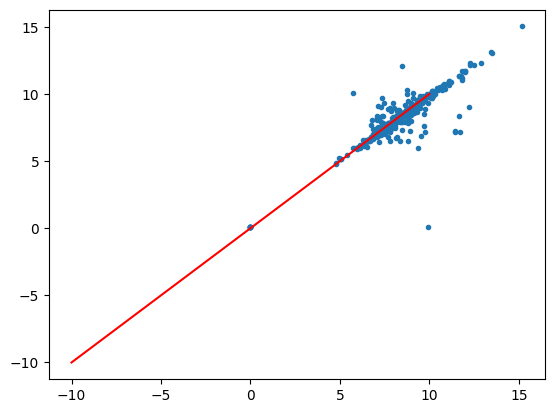

In [41]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [-10, 10],[-10, 10], 'red' )

## Quality of prediction: closest points

#### Creating df with means of classes

In [42]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds]

In [43]:
train_val_df = pd.DataFrame(y_train.cpu())
train_val_df = pd.concat([train_val_df, 
                                    pd.DataFrame(y_val.cpu())])
train_val_df.columns = elements_names
train_val_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
train_val_df.reset_index(drop=True, inplace=True)

In [44]:
mean_df = train_val_df[['Sample_id']]

for name in elements_names:
    mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)

mean_df['Sample_id'] = mean_df['Sample_id'].astype(str)
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_8743/1503384335.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_8743/1503384335.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_8743/1503384335.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

#### Checking if there is any chance for it to work: if classes in y_test are close to means of classes in train_val set

In [45]:
y_test_df = pd.DataFrame(y_test.cpu())
y_test_df.columns = elements_names
y_test_df.insert(0, 'Sample_id', test_order)
y_test_df.reset_index(drop=True, inplace=True)

In [46]:
closest = []
for i in range(y_test_df.shape[0]):
    which_row = (abs(y_test_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [47]:
len(closest)

498

In [48]:
y_test_df['Closest'] = closest

In [49]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] 

473

In [50]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] / len(closest)

0.9497991967871486

#### Now let's check if it works for the neural network's output.

In [51]:
model.eval()
outputs = model(X_test)

In [52]:
outputs_df = pd.DataFrame(outputs.cpu().detach().numpy())
outputs_df.columns = elements_names
outputs_df.insert(0, 'Real sample_id', test_order)
outputs_df['Real sample_id'] = outputs_df['Real sample_id'].astype(str)
outputs_df.reset_index(drop=True, inplace=True)

In [53]:
closest = []
for i in range(outputs_df.shape[0]):
    which_row = (abs(outputs_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [54]:
len(closest)

498

In [55]:
outputs_df['Closest'] = closest

In [56]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0]

393

In [57]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0] / len(closest) #1024, dropout 0.01

0.7891566265060241

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from seaborn import heatmap

In [59]:
acc = np.round(100*outputs_df[outputs_df['Real sample_id'] == outputs_df['Closest']].shape[0] / len(closest), 1)
print('Accuracy: '+str(acc)+'%.')

Accuracy: 78.9%.


In [60]:
normalization_in_conf_mat = None

conf_mat = confusion_matrix(outputs_df['Real sample_id'], outputs_df['Closest'], 
                            normalize=normalization_in_conf_mat)

tp_and_fn = conf_mat.sum(1)
tp_and_fp = conf_mat.sum(0)
tp = conf_mat.diagonal()

precision = tp / tp_and_fp
recall = tp / tp_and_fn

print('Precision: ' + str(np.nanmean(precision)))
print('Recall: ' + str(np.nanmean(recall)))

Precision: 0.819304921359716
Recall: 0.8199404761904762


/tmp/ipykernel_8743/2917754103.py:10: RuntimeWarning: invalid value encountered in divide
  precision = tp / tp_and_fp
/tmp/ipykernel_8743/2917754103.py:11: RuntimeWarning: invalid value encountered in divide
  recall = tp / tp_and_fn


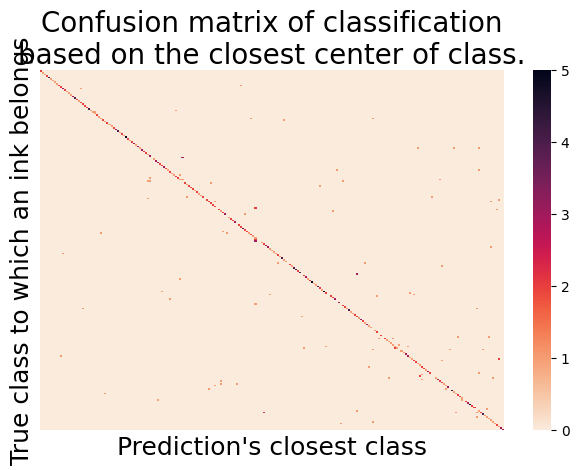

In [61]:
normalization_in_conf_mat = None
scores = {
            'pred': 'Precision',
            'true': 'Recall',
            None: 'Confusion matrix'
            }

conf_mat = confusion_matrix(outputs_df['Real sample_id'], outputs_df['Closest'], 
                            normalize=normalization_in_conf_mat)

heatmap(conf_mat, cmap=sns.cm.rocket_r, xticklabels=False, yticklabels=False)
plt.ylabel('True class to which an ink belongs', size=18)
plt.xlabel("Prediction's closest class", size=18)
plt.rcParams['figure.figsize'] = [15, 10]
plt.title(scores[normalization_in_conf_mat] + ' of classification based on the closest center of class.', 
          size=20, 
          wrap=True)

plt.tight_layout()
#plt.savefig('../figures/heatmap_' + scores[normalization_in_conf_mat] + '.png')

## Quality of prediction: confidence intervals

In [62]:
model.eval()
outputs = model(X_test)

In [63]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds]

In [64]:
all_data_df = pd.DataFrame(y_train.cpu())
all_data_df = pd.concat([all_data_df, 
                        pd.DataFrame(y_val.cpu())])
all_data_df.columns = elements_names
all_data_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
all_data_df.reset_index(drop=True, inplace=True)

In [65]:
min_max_df = all_data_df[['Sample_id']]

for name in elements_names:
    min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    min_max_df[name + '_min'] = all_data_df.groupby('Sample_id')[name].transform('min')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
        
min_max_df.sort_values(by='Sample_id', inplace=True)
min_max_df.reset_index(drop=True, inplace=True)

max_df = min_max_df.iloc[:,1:(1+len(elements_names))]
max_df['Sample_id'] = min_max_df['Sample_id']
min_df = min_max_df.iloc[:,1+len(elements_names):]
min_df['Sample_id'] = min_max_df['Sample_id']

/tmp/ipykernel_8743/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
/tmp/ipykernel_8743/3264826654.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_8743/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

In [66]:
mean_sd_df = all_data_df[['Sample_id']]

for name in elements_names:
    mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    mean_sd_df[name + '_sd'] = all_data_df.groupby('Sample_id')[name].transform(np.std)
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_sd_df.sort_values(by='Sample_id', inplace=True)
mean_sd_df.reset_index(drop=True, inplace=True)

upper_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values + \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
upper_bound_df = pd.DataFrame(upper_bound_df, columns=elements_names)
upper_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

lower_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values - \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
lower_bound_df = pd.DataFrame(lower_bound_df, columns=elements_names)
lower_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

/tmp/ipykernel_8743/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_8743/2008320981.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_8743/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [67]:
min_max_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater_than_min = test_example.cpu().detach().numpy() > \
                    np.array(min_df.loc[min_df['Sample_id'] == sample_id, min_df.columns != 'Sample_id'])
    
    less_than_max = test_example.cpu().detach().numpy() < \
                    np.array(max_df.loc[max_df['Sample_id'] == sample_id, max_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater_than_min, less_than_max)
    
    #print(res)
    min_max_res_list.append(res)

In [68]:
sd_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater = test_example.cpu().detach().numpy() > \
    np.array(lower_bound_df.loc[lower_bound_df['Sample_id'] == sample_id, lower_bound_df.columns != 'Sample_id'])
    
    less = test_example.cpu().detach().numpy() < \
    np.array(upper_bound_df.loc[upper_bound_df['Sample_id'] == sample_id, upper_bound_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater, less)
    
    #print(res)
    sd_res_list.append(res)

In [69]:
elements_names

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb']

Percentage of points inside mean +- 2 standard deviations interval:

In [70]:
np.array(sd_res_list).mean()

np.float64(0.7181224899598394)

On consecutive coordinates:

In [71]:
np.array(sd_res_list).mean(0)

array([[0.70481928, 0.75903614, 0.81726908, 0.70481928, 0.75100402,
        0.64859438, 0.63855422, 0.72088353]])

Percentage of points inside min-max interval:

In [72]:
np.array(min_max_res_list).mean()

np.float64(0.5863453815261044)

On consecutive coordinates:

In [73]:
np.array(min_max_res_list).mean(0)

array([[0.55823293, 0.64859438, 0.69076305, 0.562249  , 0.63253012,
        0.51204819, 0.50401606, 0.58232932]])

### Visualisations of mean +- 2 * standard deviation intervals

In [74]:
# fig, ax = plt.subplots(2,4, figsize=(15,8))
# plt.suptitle('Mean +- two standard deviations in classes')
# for sample_id in range(min_max_df.shape[0]):
#     for element in range(int((min_max_df.shape[1]-1)/2)):
#         ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
#                   xmax=upper_bound_df.iloc[sample_id, element], 
#                   color="blue", linewidth=1)
#         ax[element//4][element%4].set_title(elements_names[element], size=15)
#         if element == 5:
#             ax[element//4][element%4].set_xlim([-0.2, 2.0])
#         if element == 0 or element == 4:
#             ax[element//4][element%4].set_ylabel('Class number')
    
#plt.savefig(figures_path + 'intervals.png', dpi=300)

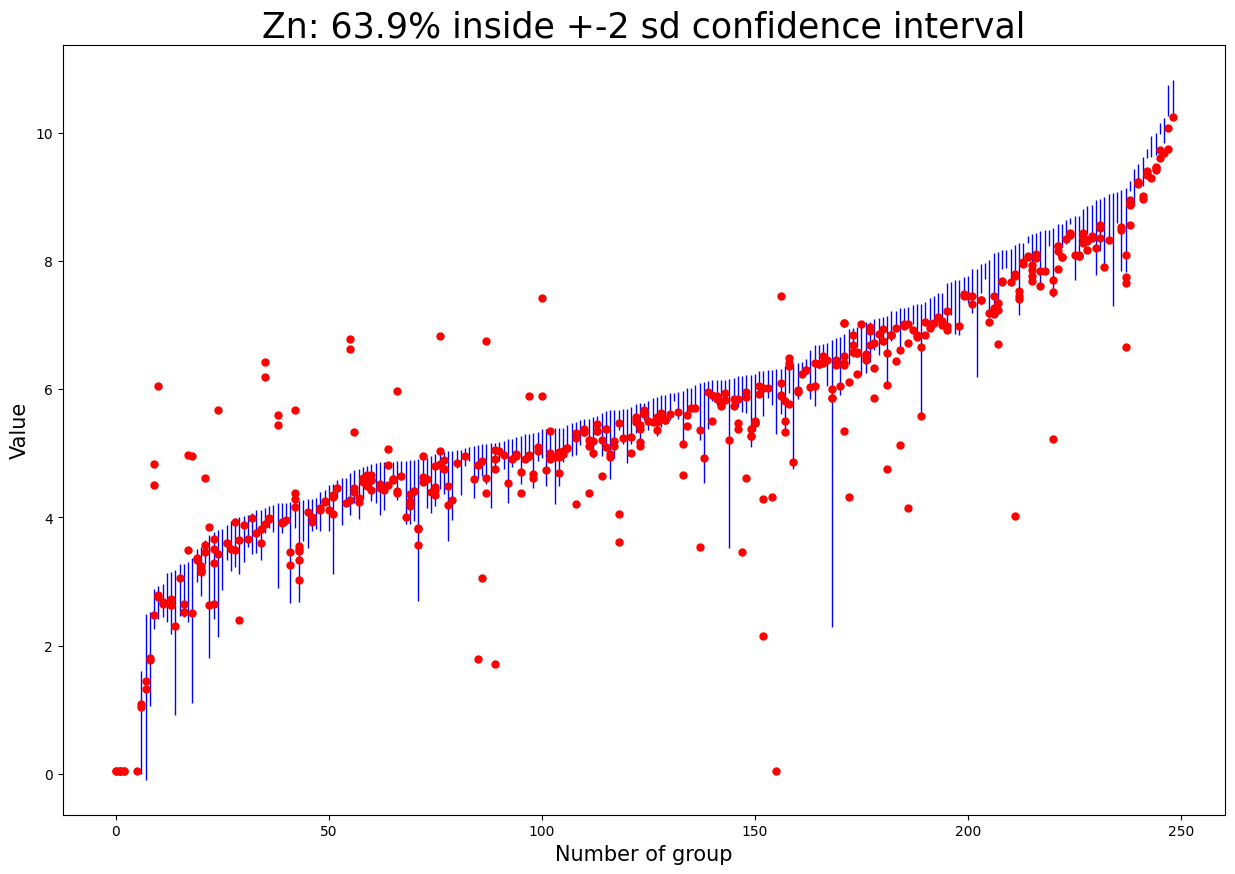

In [75]:
element = 6
percentage_correct = np.round(100*(np.array(sd_res_list).mean(0))[0,element], 1)

sorted_upper_bound_df = upper_bound_df.sort_values(upper_bound_df.columns[element])
sorted_upper_bound_df.reset_index(drop=True, inplace=True)
sorted_lower_bound_df = lower_bound_df.iloc[upper_bound_df.sort_values(upper_bound_df.columns[element]).index,:]
sorted_lower_bound_df.reset_index(drop=True, inplace=True)

for sample_id in range(sorted_lower_bound_df.shape[0]):
    plt.vlines(x=sample_id, ymin=sorted_lower_bound_df.iloc[sample_id, element], 
                  ymax=sorted_upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
    
for row in range(outputs_df.shape[0]):
    new_index = sorted_upper_bound_df[sorted_upper_bound_df['Sample_id']==outputs_df['Real sample_id'][row]].index
    plt.plot(new_index, outputs_df.iloc[row,element+1], 'ro', markersize=5)
        
plt.xlabel('Number of group',size=15)
plt.ylabel('Value',size=15)
plt.title(str(outputs_df.columns[element+1]) + ': '+str(percentage_correct) +'% inside +-2 sd confidence interval', size=25)
plt.rcParams['figure.figsize'] = [20, 20]
#plt.savefig('../figures/confidence_intervals_'+str(outputs_df.columns[element+1]))

### Visualisations of min-max intervals

In [76]:
# fig, ax = plt.subplots(2,4, figsize=(10,5))
# for sample_id in range(min_max_df.shape[0]):
#     for element in range(int((min_max_df.shape[1]-1)/2)):
#         ax[element//4][element%4].vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
#                   ymax=min_max_df.iloc[sample_id, element+1], 
#                   color="blue", linewidth=1)
        #ax[element%4][element%2].set_title(elements_names[element])

For a single element:

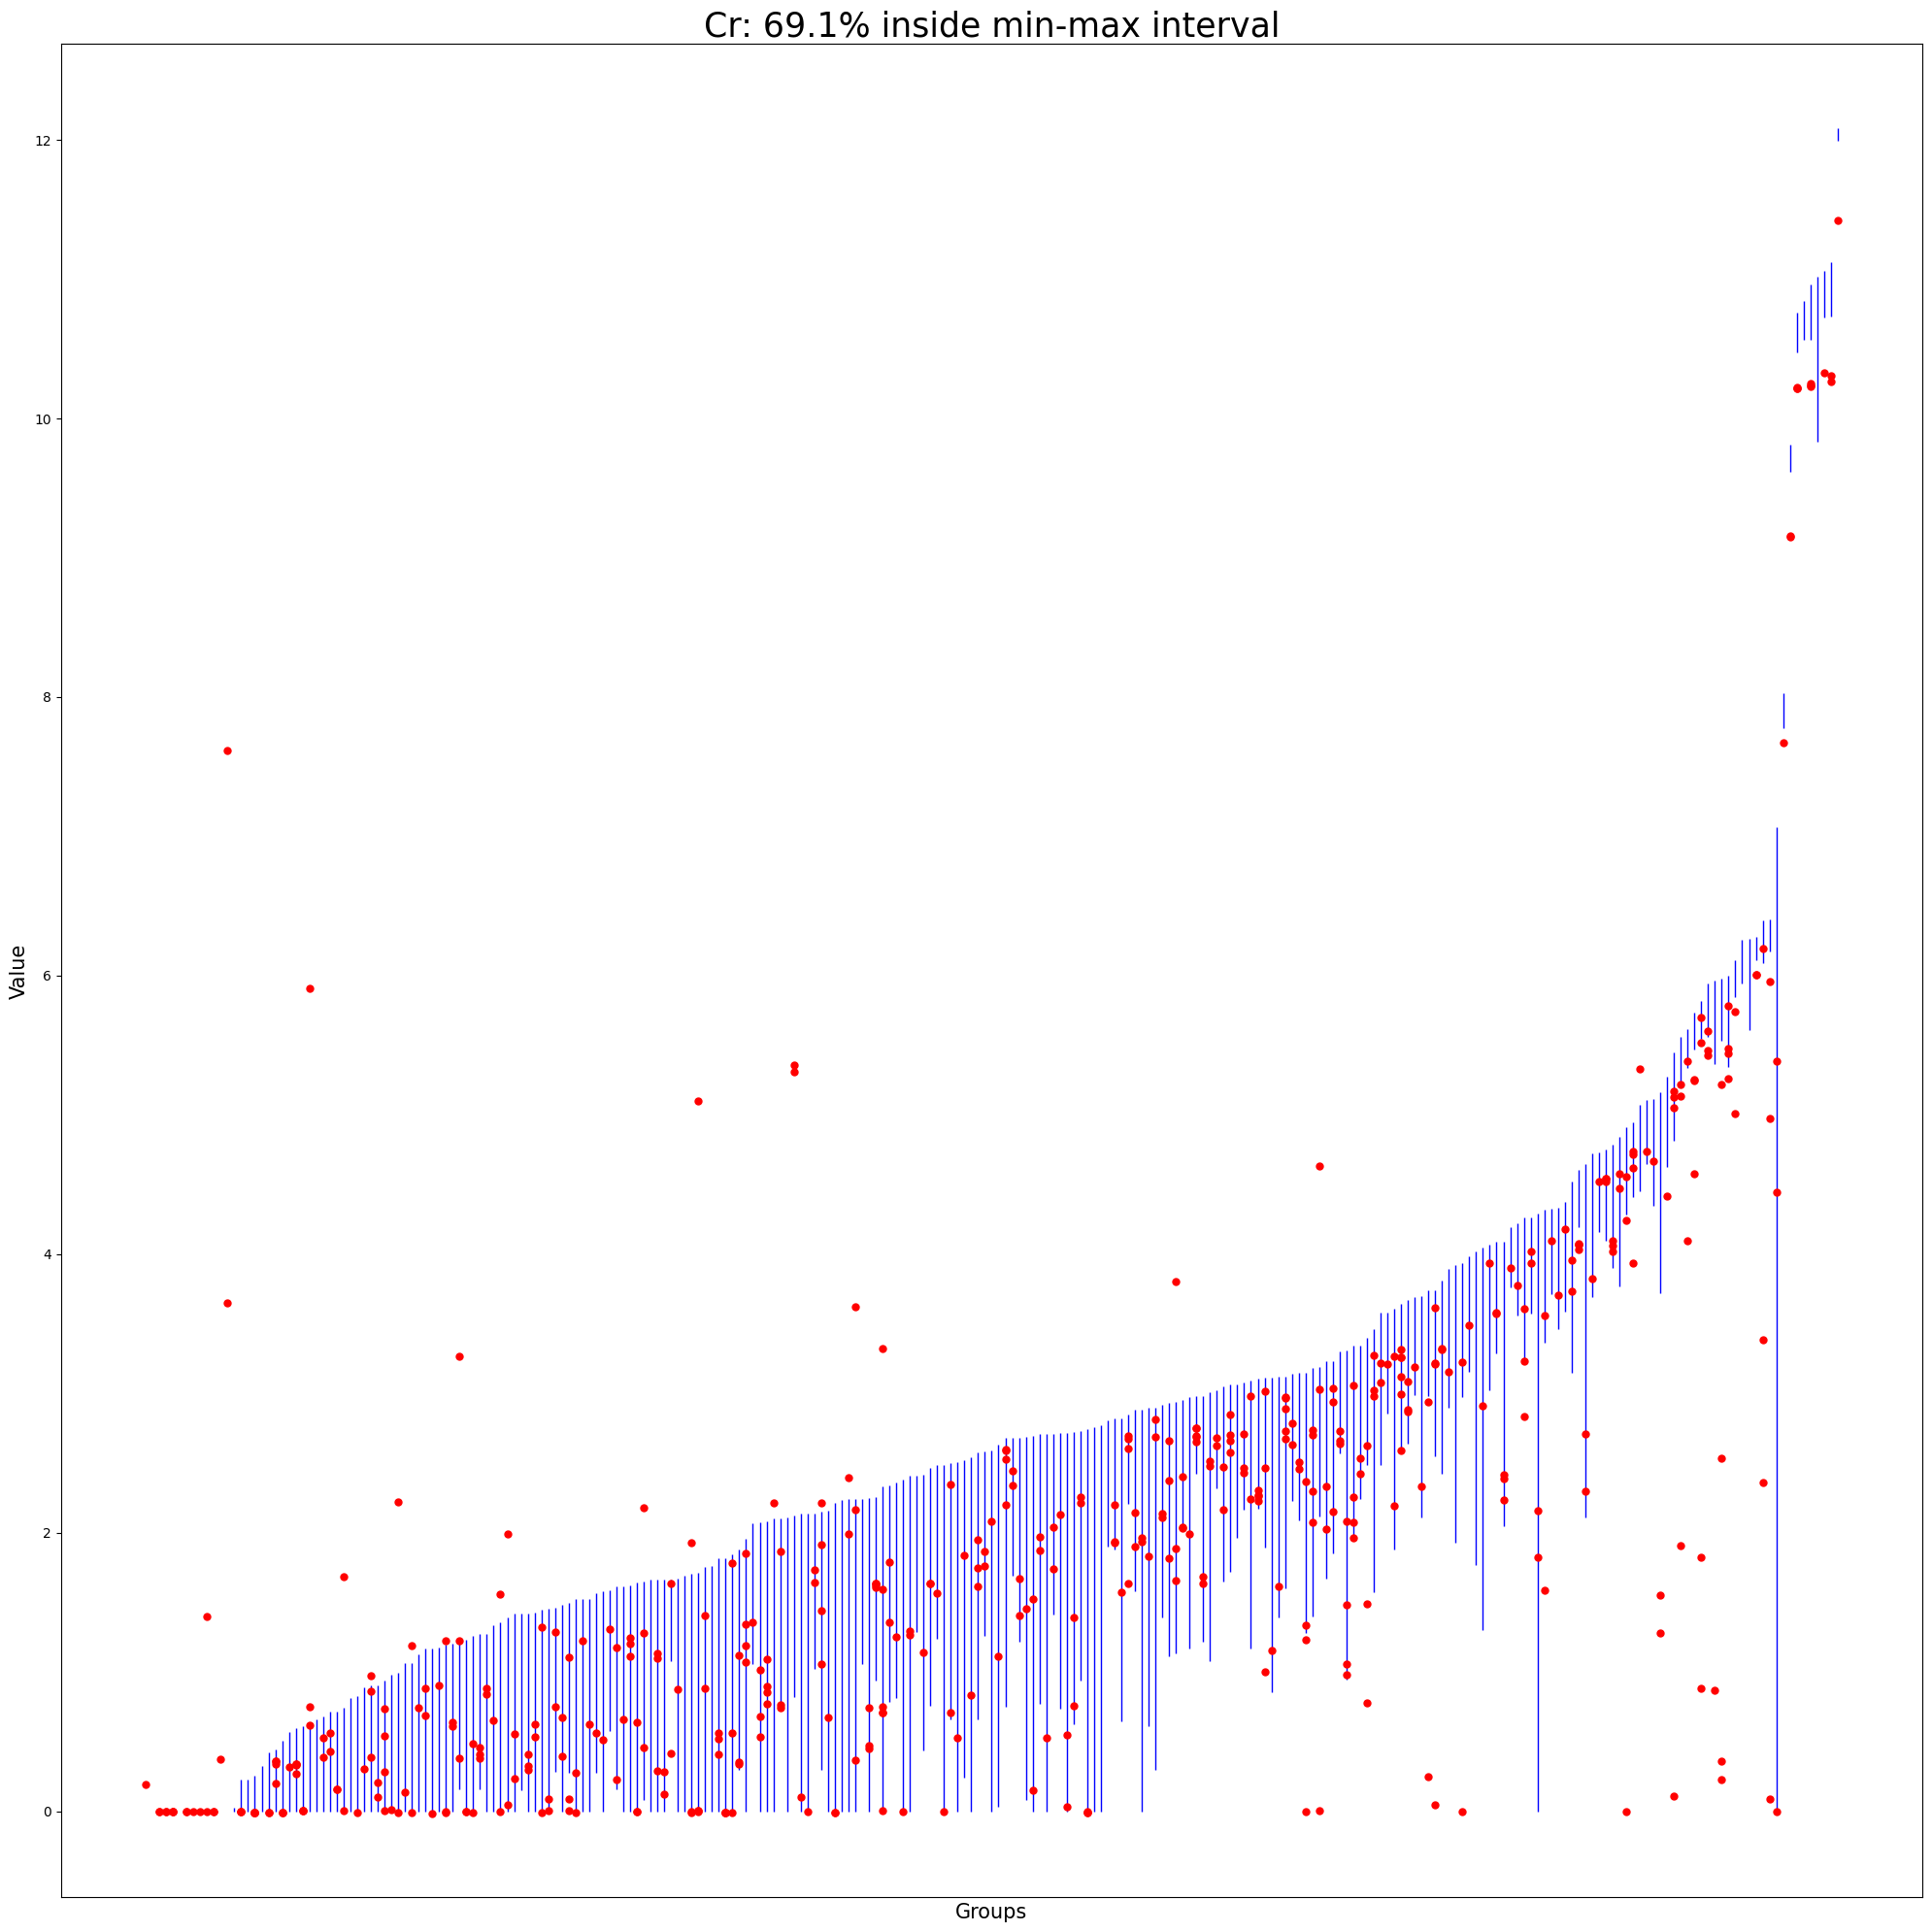

In [77]:
element = 2
percentage_correct = np.round(100*(np.array(min_max_res_list).mean(0))[0,element], 1)

sorted_min_max_df = min_max_df.sort_values(min_max_df.columns[element+1])
sorted_min_max_df.reset_index(drop=True, inplace=True)

for sample_id in range(sorted_min_max_df.shape[0]):
    plt.vlines(x=sample_id, ymin=sorted_min_max_df.iloc[sample_id, element+9], 
                  ymax=sorted_min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)

for row in range(outputs_df.shape[0]):
    new_index = sorted_min_max_df[sorted_min_max_df['Sample_id']==outputs_df['Real sample_id'][row]].index
    plt.plot(new_index, outputs_df.iloc[row,element+1], 'ro', markersize=5)
        
plt.xticks([], [])
plt.xlabel('Groups',size=15)
plt.ylabel('Value',size=15)
plt.title(str(outputs_df.columns[element+1]) + ': '+str(percentage_correct) +'% inside min-max interval', size=25)
plt.rcParams['figure.figsize'] = [20, 20]
plt.tight_layout()

#plt.savefig('../figures/min_max_intervals_'+str(outputs_df.columns[element+1]))

## Interpretability